# Save the data in the right format

In [2]:
import numpy as np
import torchvision.transforms as transforms
import h5py
from scipy import ndimage
import os
import matplotlib.pyplot as plt

jw = np.load('../data/jwst_data.npy')
eu = np.load('../data/nisp_data.npy')
jw.shape


(38974, 34, 34)

# Dataloader that works with the hdf5 and can load both lr/hr for training and only lr for inference

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
import h5py

class SuperResolutionDataset(Dataset):
    def __init__(self, lr_hdf5_path, hr_hdf5_path=None, transform=None, inference_mode=False):
        """
        Dataset that loads LR images and optionally HR images.

        :param lr_hdf5_path: Path to Low-Resolution HDF5 file
        :param hr_hdf5_path: Path to High-Resolution HDF5 file (optional)
        :param transform: Optional torchvision transforms
        :param inference_mode: If True, returns only LR images (for super-res inference)
        """
        self.lr_hdf5_path = lr_hdf5_path
        self.hr_hdf5_path = hr_hdf5_path  # Can be None
        self.transform = transform
        self.inference_mode = inference_mode  # If True, load only LR

        # Load keys from LR file
        with h5py.File(self.lr_hdf5_path, 'r') as lr_hdf5:
            self.keys = list(lr_hdf5["train_keys"][:])  # Store keys

        # Check if HR exists
        self.has_hr = hr_hdf5_path is not None

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        key = str(int(self.keys[idx]))  # Ensure key is string format

        # Open HDF5 files inside __getitem__ (for multiprocessing)
        with h5py.File(self.lr_hdf5_path, 'r') as lr_hdf5:
            lr_image = lr_hdf5["train_img"][idx, ...]  # (1, 20, 20)

        # Convert to tensor
        lr_image = torch.tensor(lr_image, dtype=torch.float32)

        # If in inference mode OR no HR data, return only LR image
        if self.inference_mode or not self.has_hr:
            return lr_image

        # Load HR image only if available
        with h5py.File(self.hr_hdf5_path, 'r') as hr_hdf5:
            hr_image = hr_hdf5["train_img"][idx, ...]  # (1, 34, 34)
            hr_image = torch.tensor(hr_image, dtype=torch.float32)
            return lr_image, hr_image  # Training case (LR, HR)



In [7]:
# Training with LR and HR
dataset = SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5")
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Get a batch for training
lr_batch, hr_batch = next(iter(dataloader))
print("Training Mode:")
print("LR Batch Shape:", lr_batch.shape)  # (16, 1, 20, 20)
print("HR Batch Shape:", hr_batch.shape)  # (16, 1, 36, 36)

# Inference with only LR
dataset = SuperResolutionDataset("../data/Nisp_train.hdf5", inference_mode=True)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

# Get a batch for inference
lr_batch = next(iter(dataloader))  # Only LR images
print("Inference Mode:")
print("LR Batch Shape:", lr_batch.shape)  # (16, 1, 20, 20)


Training Mode:
LR Batch Shape: torch.Size([16, 1, 20, 20])
HR Batch Shape: torch.Size([16, 1, 34, 34])
Inference Mode:
LR Batch Shape: torch.Size([16, 1, 20, 20])


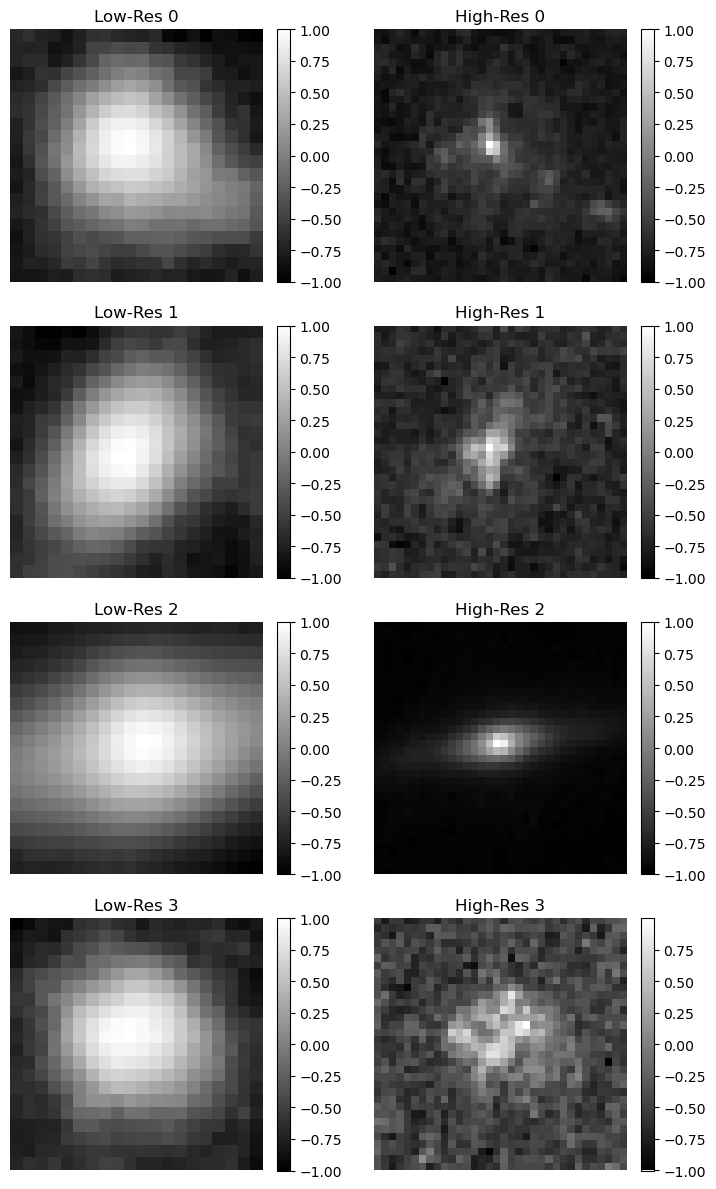

In [9]:
# Load the dataset
dataset = SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5")
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Fetch a batch
lr_batch, hr_batch = next(iter(dataloader))

# Convert tensors to NumPy
lr_batch_np = lr_batch.squeeze().cpu().numpy()  # Shape: (16, 20, 20)
hr_batch_np = hr_batch.squeeze().cpu().numpy()  # Shape: (16, 34, 34)

# Plot first 4 samples
fig, axes = plt.subplots(4, 2, figsize=(8, 12))

for i in range(4):
    # Low-Res Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)  # Add colorbar

    # High-Res Image
    img2 = axes[i, 1].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"High-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)  # Add colorbar

plt.tight_layout()
plt.show()


# Diffusion based model

In [12]:
import torch
import torch.nn as nn

# UNet with Cross-Attention
class SuperResDiffusionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, hidden_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim * 2, 3, padding=1, stride=2),
            nn.ReLU(),
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 3, padding=1, stride=2),
            nn.ReLU(),
        )

        # Ensure condition matches x channels
        self.condition_proj = nn.Conv2d(1, hidden_dim * 4, kernel_size=3, padding=1)

        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_dim * 4, num_heads=4)

        # **Corrected Decoder to Maintain 34x34 Output**
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2, kernel_size=3, stride=2, padding=1, output_padding=0),  # Prevent extra expansion
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, kernel_size=3, stride=2, padding=1, output_padding=1),  # Expands to exactly 34
            nn.ReLU(),
            nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1),  # Keeps final size at 34x34
        )

    def forward(self, x, condition):
        x = self.encoder(x)
        condition = self.condition_proj(condition)  # Match channel dimension

        batch_size, channels, height, width = x.shape

        # Flatten height & width dimensions before attention
        x = x.flatten(2).permute(2, 0, 1)  # (seq_len, batch, embed_dim)
        condition = condition.flatten(2).permute(2, 0, 1)

        x, _ = self.cross_attention(x, condition, condition)  # Apply attention

        # Reshape back to image format
        x = x.permute(1, 2, 0).view(batch_size, channels, height, width)
        x = self.decoder(x)
        return x

# Diffusion Model
class DiffusionModel(nn.Module):
    def __init__(self, unet_model, timesteps=1000):
        super().__init__()
        self.unet = unet_model
        self.timesteps = timesteps

    def forward(self, x, t, condition):
        return self.unet(x, condition)

# **Corrected Upsampler for 20x20 -> 34x34**
class Upsampler(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.upsample = nn.Upsample(size=(34, 34), mode='bilinear', align_corners=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)  # Keep padding=1

    def forward(self, x):
        x = self.upsample(x)
        return self.conv(x)

# Full Model
class SuperResolutionDiffusion(nn.Module):
    def __init__(self, unet_model, upsampler):
        super().__init__()
        self.upsampler = upsampler
        self.diffusion = DiffusionModel(unet_model)

    def forward(self, x, t):
        upscaled = self.upsampler(x)  # 20x20 -> 34x34

        # Add progressive noise instead of replacing
        noise = torch.randn_like(upscaled)
        alpha_t = torch.sqrt(1 - (t / self.diffusion.timesteps).float().view(-1, 1, 1, 1))
        noisy_image = alpha_t * upscaled + (1 - alpha_t) * noise

        return self.diffusion(noisy_image, t, upscaled)

# Instantiate models
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1)  
upsampler = Upsampler()
model = SuperResolutionDiffusion(unet, upsampler)

# Example input
x = torch.randn(1, 1, 20, 20)  # Low-res input
t = torch.tensor([500])  # Midpoint timestep in diffusion
output = model(x, t)

print("Output shape:", output.shape)  # **Should now be [1, 1, 34, 34]**


Output shape: torch.Size([1, 1, 34, 34])


# Train

In [15]:
import torch.nn as nn
import torch.optim as optim

# Use Mean Squared Error (MSE) Loss for Super-Resolution
criterion = nn.MSELoss()


# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

import time

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Number of epochs
num_epochs = 10

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    for lr_batch, hr_batch in dataloader:
        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

        # Pick random timesteps for diffusion
        t = torch.randint(0, model.diffusion.timesteps, (lr_batch.shape[0],), device=device)

        # Forward pass
        output = model(lr_batch, t)

        # Compute loss
        loss = criterion(output, hr_batch)
        epoch_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = epoch_loss / len(dataloader)
    elapsed_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, Time: {elapsed_time:.2f}s")


Epoch [1/10], Loss: 0.141279, Time: 15.54s
Epoch [2/10], Loss: 0.059947, Time: 15.78s
Epoch [3/10], Loss: 0.057163, Time: 15.52s
Epoch [4/10], Loss: 0.055241, Time: 15.55s
Epoch [5/10], Loss: 0.053975, Time: 15.54s
Epoch [6/10], Loss: 0.053051, Time: 15.46s
Epoch [7/10], Loss: 0.053357, Time: 15.92s
Epoch [8/10], Loss: 0.053076, Time: 15.70s
Epoch [9/10], Loss: 0.053277, Time: 15.80s
Epoch [10/10], Loss: 0.052251, Time: 15.71s


# Evaluate 

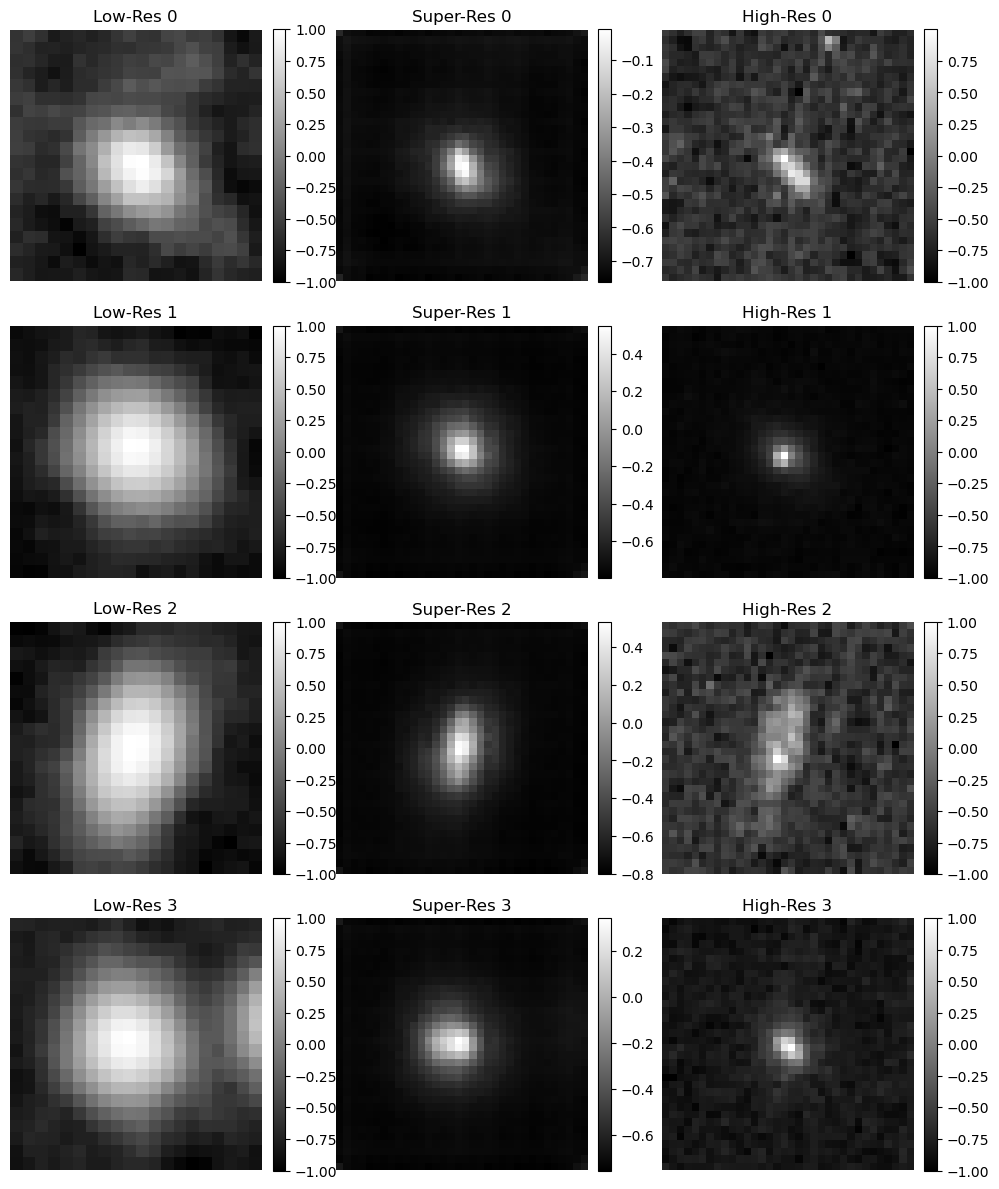

In [17]:
# Set model to evaluation mode
model.eval()

# Fetch a test batch
lr_batch, hr_batch = next(iter(dataloader))
lr_batch = lr_batch.to(device)

# Pick a few images to visualize
num_images = 4  # Adjust as needed
fig, axes = plt.subplots(num_images, 3, figsize=(10, 12))

# Generate super-resolution (SR) images
with torch.no_grad():
    t_test = torch.zeros((lr_batch.shape[0],), dtype=torch.long, device=device)  # Set t=0 for final reconstruction
    sr_batch = model(lr_batch, t_test).cpu()  # Super-resolved output

# Convert tensors to NumPy for visualization
lr_batch_np = lr_batch.cpu().squeeze().numpy()  # (batch, 20, 20)
sr_batch_np = sr_batch.cpu().squeeze().numpy()  # (batch, 34, 34)
hr_batch_np = hr_batch.cpu().squeeze().numpy()  # (batch, 34, 34)

# Plot results
for i in range(num_images):
    # Low-Resolution Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # Super-Resolved Image
    img2 = axes[i, 1].imshow(sr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"Super-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # High-Resolution Image (Ground Truth)
    img3 = axes[i, 2].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 2].set_title(f"High-Res {i}")
    axes[i, 2].axis("off")
    fig.colorbar(img3, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [ ]:
import torchmetrics
from skimage.metrics import structural_similarity as ssim
import numpy as np

# PSNR function
def compute_psnr(pred, target):
    psnr = torchmetrics.functional.peak_signal_noise_ratio(pred, target)
    return psnr.item()

# SSIM function
def compute_ssim(pred, target):
    pred_np = pred.squeeze().cpu().numpy()
    target_np = target.squeeze().cpu().numpy()
    return ssim(pred_np, target_np, data_range=target_np.max() - target_np.min())

# Evaluate model
model.eval()
lr_test, hr_test = dataset[0]  # Fetch a single test example
lr_test = lr_test.unsqueeze(0).to(device)

with torch.no_grad():
    t_test = torch.tensor([0], device=device)  # At t=0 for final reconstruction
    predicted_hr = model(lr_test, t_test).cpu()

psnr_value = compute_psnr(predicted_hr, hr_test.unsqueeze(0))
ssim_value = compute_ssim(predicted_hr, hr_test.unsqueeze(0))

print(f"PSNR: {psnr_value:.2f} dB")
print(f"SSIM: {ssim_value:.3f}")
